# Denoising Autoencoder (DAE) - MNIST Image Reconstruction

This project extends the standard Autoencoder by training the model to reconstruct clean MNIST images from deliberately corrupted inputs. The encoder-decoder architecture is used to learn representations that preserve the underlying structure of handwritten digits while reducing the effect of input noise.

## 1. Import Required Libraries

Import the libraries needed for data processing, visualization, model construction and evaluation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


## 2. Load the MNIST Dataset

Load the official MNIST dataset, normalize pixel values, flatten the images, and create a validation split.

In [2]:
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape((-1, 784))
x_test = x_test.reshape((-1, 784))

x_train, x_val = train_test_split(
    x_train,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", x_train.shape[0])
print("Validation Samples:", x_val.shape[0])
print("Test Samples:", x_test.shape[0])

Training Samples: 48000
Validation Samples: 12000
Test Samples: 10000


## 3. Create Noisy Inputs

Add Gaussian noise to the inputs while retaining the clean images as reconstruction targets.

In [3]:
noise_factor = 0.30

rng = np.random.default_rng(42)

x_train_noisy = np.clip(
    x_train + noise_factor * rng.normal(0.0, 1.0, x_train.shape),
    0.0, 1.0
)

x_val_noisy = np.clip(
    x_val + noise_factor * rng.normal(0.0, 1.0, x_val.shape),
    0.0, 1.0
)

x_test_noisy = np.clip(
    x_test + noise_factor * rng.normal(0.0, 1.0, x_test.shape),
    0.0, 1.0
)

print(f"Noise Factor: {noise_factor}")

Noise Factor: 0.3


## 4. Explore Clean and Noisy Images

Compare representative clean and corrupted images before training.

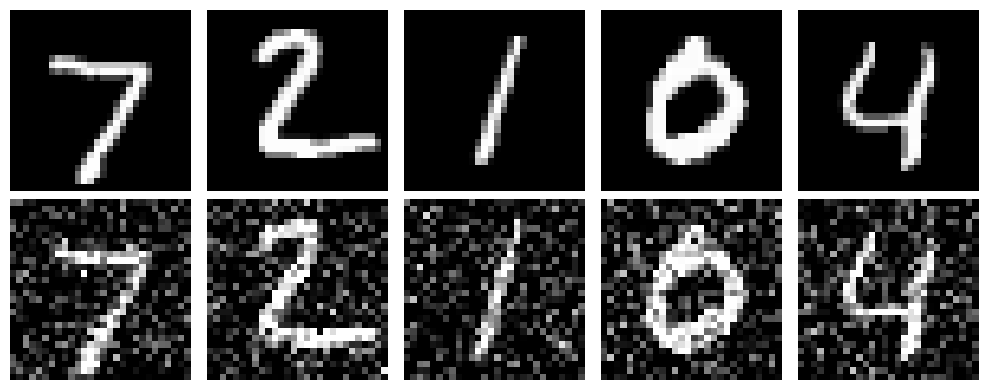

In [4]:
n = 5

fig, ax = plt.subplots(2, n, figsize=(10, 4))

for i in range(n):
    ax[0, i].imshow(x_test[i].reshape(28, 28), cmap="gray")
    ax[0, i].axis("off")
    ax[1, i].imshow(x_test_noisy[i].reshape(28, 28), cmap="gray")
    ax[1, i].axis("off")

ax[0, 0].set_ylabel("Clean")
ax[1, 0].set_ylabel("Noisy")

plt.tight_layout()
plt.show()

## 5. Build the Denoising Autoencoder

Construct the encoder, 64-dimensional bottleneck, and decoder. The model receives noisy images but is trained against clean targets.

In [5]:
inputs = Input(shape=(784,))

x = Dense(256, activation="relu")(inputs)
x = Dense(128, activation="relu")(x)
latent = Dense(64, activation="relu", name="latent_space")(x)

x = Dense(128, activation="relu")(latent)
x = Dense(256, activation="relu")(x)
outputs = Dense(784, activation="sigmoid")(x)

denoising_autoencoder = Model(inputs, outputs)

denoising_autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

denoising_autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 484,944 (1.85 MB)

 Trainable params: 484,944 (1.85 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Train the Model

Train the network to map noisy images back to their clean counterparts while monitoring validation reconstruction loss.

In [6]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = denoising_autoencoder.fit(
    x_train_noisy,
    x_train,
    validation_data=(x_val_noisy, x_val),
    epochs=30,
    batch_size=256,
    callbacks=[early_stopping]
)

best_epoch = int(np.argmin(history.history["val_loss"]) + 1)

print("Best Epoch:", best_epoch)
print(
    "Best Validation Loss:",
    f"{history.history['val_loss'][best_epoch - 1]:.6f}"
)

Epoch 1/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0623 - val_loss: 0.0360
Epoch 2/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0295 - val_loss: 0.0252
Epoch 3/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0231 - val_loss: 0.0213
Epoch 4/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0201 - val_loss: 0.0194
Epoch 5/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0183 - val_loss: 0.0179
Epoch 6/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0171 - val_loss: 0.0168
Epoch 7/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0160 - val_loss: 0.0159
Epoch 8/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0151 - val_loss: 0.0151
Epoch 9/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0145 - val_loss: 0.0145
Epoch 10/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0140 - val_loss: 0.0146
Epoch 11/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0135 - val_loss: 0.0137
Epoch 12/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step

## 7. Training Curves

Inspect training and validation reconstruction loss to assess convergence and generalization.

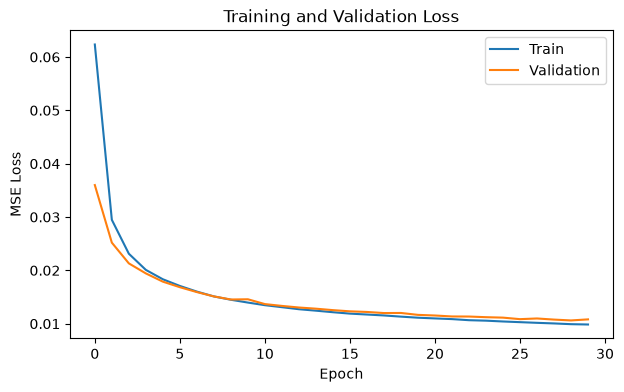

In [7]:
plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

## 8. Reconstruct Test Images

Generate denoised reconstructions from noisy test images using the best restored model.

In [8]:
reconstructed = denoising_autoencoder.predict(
    x_test_noisy,
    verbose=0
)

## 9. Visual Comparison

Compare clean targets, noisy inputs, and reconstructed outputs to assess how effectively the model removes noise.

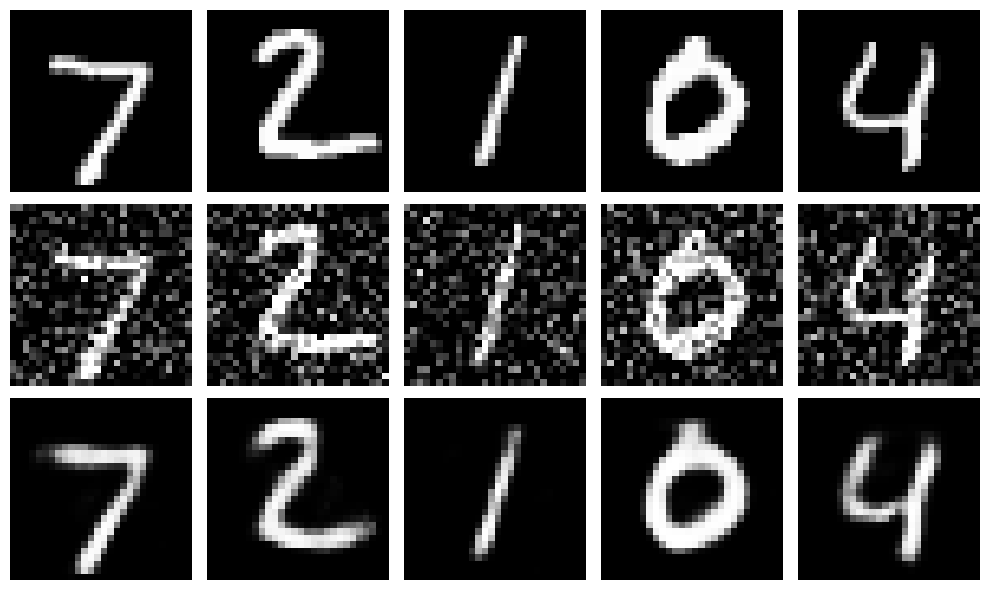

In [9]:
n = 5

fig, ax = plt.subplots(3, n, figsize=(10, 6))

for i in range(n):
    ax[0, i].imshow(x_test[i].reshape(28, 28), cmap="gray")
    ax[0, i].axis("off")
    ax[1, i].imshow(x_test_noisy[i].reshape(28, 28), cmap="gray")
    ax[1, i].axis("off")
    ax[2, i].imshow(reconstructed[i].reshape(28, 28), cmap="gray")
    ax[2, i].axis("off")

ax[0, 0].set_ylabel("Clean")
ax[1, 0].set_ylabel("Noisy")
ax[2, 0].set_ylabel("Reconstructed")

plt.tight_layout()
plt.show()

## 10. Reconstruction Error Analysis

Quantify reconstruction quality across the test set using per-image mean squared error.

Mean Reconstruction Error: 0.010230
Median Reconstruction Error: 0.009636
Maximum Reconstruction Error: 0.040900


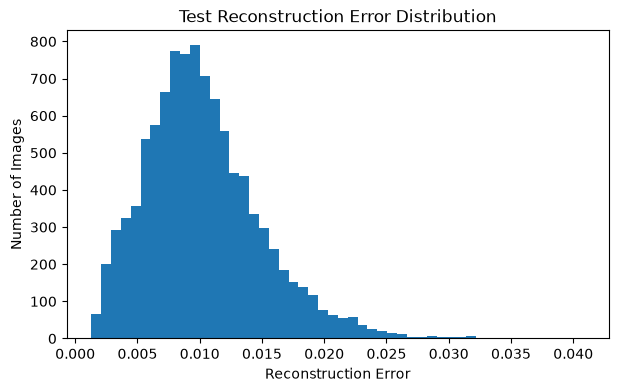

In [10]:
mse = np.mean(np.square(x_test - reconstructed), axis=1)

print(f"Mean Reconstruction Error: {mse.mean():.6f}")
print(f"Median Reconstruction Error: {np.median(mse):.6f}")
print(f"Maximum Reconstruction Error: {mse.max():.6f}")

plt.figure(figsize=(7, 4))
plt.hist(mse, bins=50)
plt.xlabel("Reconstruction Error")
plt.ylabel("Number of Images")
plt.title("Test Reconstruction Error Distribution")
plt.show()

## 11. Latent Representation

Extract the learned 64-dimensional latent vectors to inspect the compressed representation produced by the encoder.

In [11]:
encoder = Model(inputs, latent)

latent_vectors = encoder.predict(
    x_test[:10],
    verbose=0
)

print("Latent Representation Shape:", latent_vectors.shape)
print("\nFirst Latent Vector:")
print(latent_vectors[0])

Latent Representation Shape: (10, 64)

First Latent Vector:
[0.         1.0896895  0.         0.15208098 3.3003259  0.
 4.6637855  1.3971469  0.47046888 2.5990005  2.285786   3.4188542
 6.7038555  6.2703905  2.779177   5.966929   5.3722253  0.
 0.         0.         5.4327826  3.32962    3.723757   0.
 1.8148825  0.         0.         2.910209   3.3849516  3.6645606
 3.742477   3.6092787  5.7330422  0.         0.8572304  2.122744
 4.0933933  0.         2.291723   0.         5.634739   2.106681
 0.         1.4643943  6.71825    5.407835   4.4299507  4.2468553
 0.         0.         0.         6.6665225  2.3947313  3.6644514
 1.8351693  0.         0.         0.         1.0471048  7.2087235
 0.62633544 0.         6.162354   0.        ]


## 12. Model Evaluation

Evaluate the restored model on clean targets using noisy test images as inputs.

In [12]:
test_loss = denoising_autoencoder.evaluate(
    x_test_noisy,
    x_test,
    verbose=0
)

print(f"Test Reconstruction Loss: {test_loss:.6f}")

Test Reconstruction Loss: 0.010230


# 13. Key Findings

- The Denoising Autoencoder achieved a **test reconstruction loss of 0.010230** on noisy MNIST inputs.
- The best validation loss was **0.010612**, reached at **Epoch 29**, after which the final epoch showed a small increase in validation loss.
- The mean reconstruction error across the test set was **0.010230**, with a median of **0.009636** and a maximum of **0.040900**. 
- The model successfully learned to reconstruct clean digit structure from inputs corrupted with Gaussian noise, demonstrating that the learned latent representation captures features that are useful for denoising.
- The 784-dimensional input was compressed into a **64-dimensional latent representation**, providing a substantially lower-dimensional representation while retaining the main visual structure of the digits.

# 14. Conclusion

The Denoising Autoencoder extended the standard Autoencoder by learning to reconstruct clean MNIST images from noisy inputs rather than directly reproducing clean inputs. The model achieved a test reconstruction loss of **0.010230**, while the reconstructed samples retained the main structure of the handwritten digits.

The experiment demonstrates that an Autoencoder can be trained not only for dimensionality reduction, but also to learn representations that are robust to corrupted inputs.